# 2025 Urban Heat Index Campagin - August 18, 19, and 20. 
Brief intro. 

In [1]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
import time
import datetime as dt
import folium
import branca.colormap as cm

In [2]:
data_dir = r'C:\Users\bmaro\OneDrive - University of South Carolina\Columbia Heat Project\heat_mapping\Raw_files\renamed_files'
print(f'{len(os.listdir(data_dir))} files found in {data_dir}')

116 files found in C:\Users\bmaro\OneDrive - University of South Carolina\Columbia Heat Project\heat_mapping\Raw_files\renamed_files


In [3]:
def create_df(csv_file):
    df = pd.read_csv(csv_file)
    df = df.drop(df.index[0:6])   # The first few lines typically read funny, I will drop. First 30 seconds.
    df['datetime'] = pd.to_datetime(df['GPS_Timestamp_UTC'])
    try:
        df['datetime'] = df['datetime'].dt.tz_convert('America/New_York')
    except Exception as e:
        print(f"Error converting timezone: {e}")
        df['datetime'] = pd.to_datetime(df['GPS_Timestamp_UTC'], errors='coerce')

    # Convert 'GPS_Timestamp_UTC' to datetime objects
    df['GPS_Timestamp_UTC'] = pd.to_datetime(df['GPS_Timestamp_UTC'], errors='coerce')

    # Convert 'Temperature_C' and 'Humidity_RH' to numeric, coercing errors to NaN
    df['Temperature_C'] = pd.to_numeric(df['Temperature_C'], errors='coerce')
    df['Humidity_RH'] = pd.to_numeric(df['Humidity_RH'], errors='coerce')

    # Drop rows with NaN values in critical columns for plotting, as they would break the plot
    df.dropna(subset=['GPS_Timestamp_UTC', 'Temperature_C', 'Humidity_RH'], inplace=True)

    # I will create a geopandas dataframe as well. No need to do both.
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))

    return df, gdf

In [4]:
gdf_all = gpd.GeoDataFrame()

# Process each CSV file in the directory
for file in os.listdir(data_dir):
    if file.endswith('.csv'):
        csv_file = os.path.join(data_dir, file)
        #print(f'Processing file: {file}')
        
        # Extract date and time of day from the file name
        date = file.split('_')[1]
        #print(f'Date: {date}')
        time_of_day = int(file.split('_')[2][0:2])
        #print(f'Time of day: {time_of_day}')
        try:
            df, gdf = create_df(csv_file)
            gdf_all = pd.concat([gdf_all, gdf], ignore_index=True)
            #print(f'Processed {file}: {len(df)} rows, {len(gdf)} geometries')
        except Exception as e:
            print(f'WARNING: Error processing {file}: {e}')
        




Error converting timezone: Cannot convert tz-naive timestamps, use tz_localize to localize
Error converting timezone: Cannot convert tz-naive timestamps, use tz_localize to localize
Error converting timezone: Cannot convert tz-naive timestamps, use tz_localize to localize


In [5]:
min_speed = 2.23
max_speed = None
if min_speed is not None:
    gdf_all = gdf_all[gdf_all['Speed_mps']>min_speed]
if max_speed is not None:
    gdf_all = gdf_all[gdf_all['Speed_mps']<max_speed]


In [6]:
# Define the days and time periods of interest
days = ['2025-08-18', '2025-08-19', '2025-08-20']
periods = {
    'am': ('06:00:00', '07:00:00'),
    'af': ('19:00:00', '20:00:00'),
    'pm': ('15:00:00', '16:00:00')
}

# Dictionary to hold the resulting dataframes
dfs_by_day_period = {}

for day in days:
    for label, (start, end) in periods.items():
        start_dt = pd.Timestamp(f"{day} {start}").tz_localize('America/New_York')
        end_dt = pd.Timestamp(f"{day} {end}").tz_localize('America/New_York')
        mask = (gdf_all['datetime'] >= start_dt) & (gdf_all['datetime'] < end_dt)
        key = f"{day}_{label}"
        dfs_by_day_period[key] = gdf_all.loc[mask].copy()

# Example: dfs_by_day_period['2025-08-18_am'] contains the 6-7am data for 2025-08-18

In [7]:
for key, df in dfs_by_day_period.items():
    print(f"{key}: {len(df)} rows")
    grouped = df.groupby('RaspberryPiName').size()
    print(f"  Number of unique Raspberry Pi devices: {len(grouped)}")
    if len(df) > 0:
        df['Temperature_C'] = df['Temperature_C'].astype(float)
        df['Humidity_RH'] = df['Humidity_RH'].astype(float)
        #df['Heat_Index'] = df['Heat_Index'].astype(float)
        print(f"  Temperature range: {df['Temperature_C'].min()} to {df['Temperature_C'].max()}")
        print(f"  Humidity range: {df['Humidity_RH'].min()} to {df['Humidity_RH'].max()}")
        #print(f"  Heat Index range: {df['Heat_Index'].min()} to {df['Heat_Index'].max()}")
    else:
        print("  No data available for this period.")

2025-08-18_am: 3382 rows
  Number of unique Raspberry Pi devices: 8
  Temperature range: 22.51 to 25.34
  Humidity range: 81.29 to 97.16
2025-08-18_af: 2798 rows
  Number of unique Raspberry Pi devices: 8
  Temperature range: 24.79 to 28.85
  Humidity range: 69.73 to 97.64
2025-08-18_pm: 2771 rows
  Number of unique Raspberry Pi devices: 7
  Temperature range: 30.05 to 38.13
  Humidity range: 39.24 to 73.66
2025-08-19_am: 2578 rows
  Number of unique Raspberry Pi devices: 6
  Temperature range: 23.39 to 24.85
  Humidity range: 87.89 to 97.66
2025-08-19_af: 3189 rows
  Number of unique Raspberry Pi devices: 8
  Temperature range: 24.69 to 30.11
  Humidity range: 48.61 to 80.82
2025-08-19_pm: 2421 rows
  Number of unique Raspberry Pi devices: 6
  Temperature range: 27.62 to 33.06
  Humidity range: 57.3 to 77.86
2025-08-20_am: 2056 rows
  Number of unique Raspberry Pi devices: 5
  Temperature range: 22.18 to 23.96
  Humidity range: 84.31 to 94.57
2025-08-20_af: 4010 rows
  Number of uniqu

In [8]:
def map(gdf, filename='heat_map.html'):
    """
    Creates a map for each time window.

    Args:
        gdf (GeoDataFrame): The GeoDataFrame containing GPS points, temperature, humidity, and speed data.
        filename (str): The name of the output HTML file for the map.

    Returns:
        None: Saves the map to an HTML file.
    """

    gdf = gdf.dropna()
    # Create a colormap for temperature
    scale_min = gdf['Temperature_C'].min()
    scale_max = gdf['Temperature_C'].max()
    linear = cm.LinearColormap(["blue", "white", "red"], vmin=scale_min, vmax=scale_max)
    # Create a map centered around the first valid GPS point
    len_data = len(gdf)
    map_center = [33.998483, -81.027863]#[gdf['Latitude'].iloc[len_data//2], gdf['Longitude'].iloc[len_data//2]]
    m = folium.Map(location=map_center, zoom_start=13)
    # Add markers for each GPS point
    for idx, row in gdf.iterrows():
        sensor = row['RaspberryPiName']
        time = row['datetime']
        temp = row['Temperature_C']
        rh = row['Humidity_RH']
        spd = row['Speed_mps']
            # Get the color from the colormap based on the temperature
        marker_color = linear(temp)

        folium.CircleMarker( # Using CircleMarker for better visibility of color
            location=[row['Latitude'], row['Longitude']],
            radius=5, # Size of the circle marker
            color=marker_color, # Outline color
            fill_color=marker_color,
            fill=True,
            fill_opacity=1,
            popup=f"{sensor}\nTime: {time}\n local Temp: {temp}°C\n RH: {rh}\n Speed: {spd} mps"
        ).add_to(m)
        # Add an Esri Satellite basemap
    folium.TileLayer(tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',name='Esri Sat' , attr='Esri', overlay=False, control=True, show=False).add_to(m)

    # the layercontrol itself
    lc = folium.map.LayerControl(collapsed=False)
    lc.add_to(m)

    # Add color bar to bottom right
    linear.add_to(m)

    m.render()
    m.get_root().script = folium.Element(
        m.get_root().script.render().replace('topright', 'bottomright')
    )
    m.save(outfile=filename)
    

In [9]:
for key, df in dfs_by_day_period.items():
    # map each dataframe
    map(df, filename=f'{key}_heat_map.html')
    print(f"Map saved for {key} as {key}_heat_map.html")
    

Map saved for 2025-08-18_am as 2025-08-18_am_heat_map.html
Map saved for 2025-08-18_af as 2025-08-18_af_heat_map.html
Map saved for 2025-08-18_pm as 2025-08-18_pm_heat_map.html
Map saved for 2025-08-19_am as 2025-08-19_am_heat_map.html
Map saved for 2025-08-19_af as 2025-08-19_af_heat_map.html
Map saved for 2025-08-19_pm as 2025-08-19_pm_heat_map.html
Map saved for 2025-08-20_am as 2025-08-20_am_heat_map.html
Map saved for 2025-08-20_af as 2025-08-20_af_heat_map.html
Map saved for 2025-08-20_pm as 2025-08-20_pm_heat_map.html


In [10]:
gdf_all["RaspberryPiName"].unique()
# get counts of unique Raspberry Pi names
print(gdf_all["RaspberryPiName"].value_counts())

s00 = gdf_all[gdf_all["RaspberryPiName"] == "sensor00"]
s00.head()

RaspberryPiName
sensor06    4902
sensor07    4740
sensor08    4440
sensor03    4154
sensor04    4149
sensor05    3951
sensor01    3604
sensor00    1661
sensor10     565
sensor11     479
Name: count, dtype: int64


,System_Timestamp_UTC,RaspberryPiName,Sensor_ID,Temperature_C,Humidity_RH,GPS_Timestamp_UTC,Latitude,Longitude,Altitude_m,Speed_mps,Climb_mps,Track_deg,Satellites,GPS_Fix_Type,datetime,geometry
49,2025-08-17 16:37:58 UTC,sensor00,236492955,29.69,65.01,2025-08-17 23:46:08+00:00,34.002287,-81.013862,68.1,2.27,-0.1,276.01,7.0,3D,2025-08-17 19:46:08-04:00,POINT (-81.01386 34.00229)
50,2025-08-17 16:38:03 UTC,sensor00,236492955,29.78,64.74,2025-08-17 23:46:13+00:00,34.002260,-81.013985,67.5,2.76,-0.1,241.43,7.0,3D,2025-08-17 19:46:13-04:00,POINT (-81.01398 34.00226)
51,2025-08-17 16:38:08 UTC,sensor00,236492955,29.86,65.51,2025-08-17 23:46:18+00:00,34.002185,-81.014132,66.8,3.58,-0.2,227.84,7.0,3D,2025-08-17 19:46:18-04:00,POINT (-81.01413 34.00218)
52,2025-08-17 16:38:13 UTC,sensor00,236492955,29.82,65.32,2025-08-17 23:46:23+00:00,34.002077,-81.014277,66.1,3.30,-0.1,225.86,7.0,3D,2025-08-17 19:46:23-04:00,POINT (-81.01428 34.00208)
53,2025-08-17 16:38:18 UTC,sensor00,236492955,29.78,65.46,2025-08-17 23:46:28+00:00,34.001977,-81.014390,65.3,3.21,-0.1,228.24,7.0,3D,2025-08-17 19:46:28-04:00,POINT (-81.01439 34.00198)


# Looking at all data. Post the final days of collection


In [23]:
data_dir = r'C:\Users\bmaro\OneDrive\Desktop\New folder (2)\all_data'
print(f'{len(os.listdir(data_dir))} files found in {data_dir}')

179 files found in C:\Users\bmaro\OneDrive\Desktop\New folder (2)\all_data


In [24]:
gdf_all = gpd.GeoDataFrame()

# Process each CSV file in the directory
for file in os.listdir(data_dir):
    if file.endswith('.csv'):
        csv_file = os.path.join(data_dir, file)
        #print(f'Processing file: {file}')
        
        # Extract date and time of day from the file name
        date = file.split('_')[1]
        #print(f'Date: {date}')
        time_of_day = int(file.split('_')[2][0:2])
        #print(f'Time of day: {time_of_day}')
        try:
            df, gdf = create_df(csv_file)
            gdf_all = pd.concat([gdf_all, gdf], ignore_index=True)
            #print(f'Processed {file}: {len(df)} rows, {len(gdf)} geometries')
        except Exception as e:
            print(f'WARNING: Error processing {file}: {e}')

Error converting timezone: Cannot convert tz-naive timestamps, use tz_localize to localize
Error converting timezone: Cannot convert tz-naive timestamps, use tz_localize to localize
Error converting timezone: Cannot convert tz-naive timestamps, use tz_localize to localize
Error converting timezone: Cannot convert tz-naive timestamps, use tz_localize to localize


In [13]:
shp = gdf_all
shp.rename(columns={'System_Timestamp_UTC':'Pi_time'
                        , 'RaspberryPiName': 'PiName'
                        ,'Temperature_C': 'temp_c'
                        , 'Humidity_RH': 'rh'
                        , 'GPS_Timestamp_UTC': 'GPS_Time'
                        , 'GPS_Fix_Type': 'GPS_Fix'}, inplace=True)
shp.head()
shp = shp.set_crs(epsg=4326)

In [14]:
shp.to_file(r'C:\Users\bmaro\OneDrive - University of South Carolina\Columbia Heat Project\all_data\all_data.shp')

<Axes: >

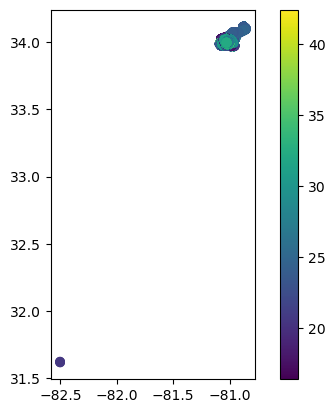

In [15]:
my_shp = gpd.read_file(r'C:\Users\bmaro\OneDrive - University of South Carolina\Columbia Heat Project\all_data\all_data.shp')
my_shp.plot(column='temp_c', legend=True)

In [16]:
# find all unique days 
my_shp['datetime'] = pd.to_datetime(my_shp['datetime'], errors='coerce')
unique_days = my_shp['datetime'].dt.date.unique()
print(f'Unique days in dataset: {unique_days}')

Unique days in dataset: [datetime.date(2025, 8, 17) datetime.date(2025, 8, 18)
 datetime.date(2025, 8, 19) datetime.date(2025, 8, 20)
 datetime.date(2025, 9, 22) datetime.date(2025, 9, 23)
 datetime.date(2025, 9, 24) datetime.date(2025, 8, 16)
 datetime.date(2025, 8, 15) datetime.date(2025, 9, 21)]


In [27]:
print(gdf_all.columns)
gdf_all.describe()

Index(['System_Timestamp_UTC', 'RaspberryPiName', 'Sensor_ID', 'Temperature_C',
       'Humidity_RH', 'GPS_Timestamp_UTC', 'Latitude', 'Longitude',
       'Altitude_m', 'Speed_mps', 'Climb_mps', 'Track_deg', 'Satellites',
       'GPS_Fix_Type', 'datetime', 'geometry'],
      dtype='object')


,Sensor_ID,Temperature_C,Humidity_RH,Latitude,Longitude,Altitude_m,Speed_mps,Climb_mps,Track_deg,Satellites
count,4.866600e+04,48666.000000,48666.000000,48666.000000,48666.000000,48666.000000,48666.000000,48666.000000,48666.000000,48666.000000
mean,2.431320e+08,27.318177,69.995731,33.997232,-81.018018,85.940745,6.616284,0.003814,143.906668,11.923930
std,2.796315e+07,4.446342,18.446611,0.012756,0.027191,27.549532,2.834872,1.785088,116.603059,3.641751
min,2.181877e+08,16.370000,19.310000,33.968383,-81.088947,-364.300000,2.240000,-170.700000,0.000000,0.000000
25%,2.182082e+08,23.900000,55.840000,33.988880,-81.035558,69.200000,4.520000,-0.200000,31.927500,10.000000
50%,2.364765e+08,28.460000,69.035000,33.997068,-81.020097,84.500000,6.010000,0.000000,136.060000,11.000000
75%,2.364973e+08,30.660000,89.050000,34.003500,-81.003877,98.900000,8.340000,0.200000,248.870000,13.000000
max,3.003722e+08,41.400000,97.660000,34.116632,-80.855705,740.400000,15.640000,124.300000,359.990000,25.000000


In [26]:
min_speed = 2.23 # 5 mph = 2.23 mps
max_speed = 15.6464 # 35 mph = 15.6464 mps
if min_speed is not None:
    gdf_all = gdf_all[gdf_all['Speed_mps']>min_speed]
if max_speed is not None:
    gdf_all = gdf_all[gdf_all['Speed_mps']<max_speed]
print(gdf_all.shape)
gdf_all = gdf_all.dropna(subset=['temp_c', 'rh', 'Latitude', 'Longitude'])
print(gdf_all.shape)


(48666, 16)


KeyError: ['temp_c', 'rh']

In [ ]:
gdf_all["RaspberryPiName"].unique()
# get counts of unique Raspberry Pi names
print(gdf_all["RaspberryPiName"].value_counts())

RaspberryPiName
sensor07    6506
sensor03    6248
sensor04    5756
sensor08    5581
sensor06    5421
sensor01    4597
sensor05    4370
sensor10    3971
sensor00    1661
sensor11     479
Name: count, dtype: int64


In [ ]:
# Define the days and time periods of interest
days = ['2025-08-18', '2025-08-19', '2025-08-20', '2025-09-23', '2025-09-24']
periods = {
    'am': ('06:00:00', '07:00:00'),
    'af': ('15:00:00', '16:00:00'),
    'pm': ('19:00:00', '20:00:00')
}

# Dictionary to hold the resulting dataframes
dfs_by_day_period = {}

for day in days:
    for label, (start, end) in periods.items():
        start_dt = pd.Timestamp(f"{day} {start}").tz_localize('America/New_York')
        end_dt = pd.Timestamp(f"{day} {end}").tz_localize('America/New_York')
        mask = (gdf_all['datetime'] >= start_dt) & (gdf_all['datetime'] < end_dt)
        key = f"{day}_{label}"
        dfs_by_day_period[key] = gdf_all.loc[mask].copy()

# Example: dfs_by_day_period['2025-08-18_am'] contains the 6-7am data for 2025-08-18

In [ ]:
daily_summaries = {}

for key, df in dfs_by_day_period.items():
    print(f"{key}: {len(df)} rows")
    grouped = df.groupby('RaspberryPiName').size()
    print(f"  Number of Instruments Deployed: {len(grouped)}")
    print(f"     Instruments by Name: {[name for name in grouped.keys()]}")
    if len(df) > 0:
        df['Temperature_C'] = df['Temperature_C'].astype(float)
        df['Humidity_RH'] = df['Humidity_RH'].astype(float)
        #df['Heat_Index'] = df['Heat_Index'].astype(float)
        desc_temp = df['Temperature_C'].describe()
        desc_rh = df['Humidity_RH'].describe()
        print("  Summary Statistics:")
        print("     Temp: ")
        print(f"        Mean: {desc_temp['mean']:.2f}°, Min: {desc_temp['min']}°, Q1: {desc_temp['25%']}°, Median: {desc_temp['50%']}°, Q3: {desc_temp['75%']}°, Max: {desc_temp['max']}°")
        print("     RH: ")
        print(f"        Mean: {desc_rh['mean']:.2f} Min: {desc_rh['min']}%, Q1: {desc_rh['25%']}%, Median: {desc_rh['50%']}%, Q3: {desc_rh['75%']}%, Max: {desc_rh['max']}%")
        daily_summaries[key] = {
            'num_instruments': len(grouped),
            'instruments': [name for name in grouped.keys()],
            'temp_summary': {
                'mean': desc_temp['mean'],
                'min': desc_temp['min'],
                'Q1': desc_temp['25%'],
                'median': desc_temp['50%'],
                'Q3': desc_temp['75%'],
                'max': desc_temp['max']
            },
            'rh_summary': {
                'mean': desc_rh['mean'],
                'min': desc_rh['min'],
                'Q1': desc_rh['25%'],
                'median': desc_rh['50%'],
                'Q3': desc_rh['75%'],
                'max': desc_rh['max']
            }
        }
    else:
        print("  No data available for this period.")

2025-08-18_am: 3348 rows
  Number of Instruments Deployed: 8
     Instruments by Name: ['sensor00', 'sensor01', 'sensor03', 'sensor04', 'sensor05', 'sensor06', 'sensor07', 'sensor08']
  Summary Statistics:
     Temp: 
        Mean: 23.72°, Min: 22.51°, Q1: 23.14°, Median: 23.58°, Q3: 24.23°, Max: 25.34°
     RH: 
        Mean: 91.13 Min: 81.29%, Q1: 89.5275%, Median: 91.52%, Q3: 93.2%, Max: 97.16%
2025-08-18_af: 2547 rows
  Number of Instruments Deployed: 7
     Instruments by Name: ['sensor00', 'sensor03', 'sensor04', 'sensor05', 'sensor06', 'sensor07', 'sensor08']
  Summary Statistics:
     Temp: 
        Mean: 32.99°, Min: 30.05°, Q1: 31.95°, Median: 32.93°, Q3: 33.92°, Max: 38.13°
     RH: 
        Mean: 55.78 Min: 39.24%, Q1: 49.58%, Median: 55.77%, Q3: 61.565%, Max: 73.66%
2025-08-18_pm: 2492 rows
  Number of Instruments Deployed: 8
     Instruments by Name: ['sensor00', 'sensor01', 'sensor03', 'sensor04', 'sensor05', 'sensor06', 'sensor07', 'sensor08']
  Summary Statistics:
    

In [ ]:
for key, df in dfs_by_day_period.items():
    # map each dataframe
    map(df, filename=f'{key}_heat_map.html')
    print(f"Map saved for {key} as {key}_heat_map.html")

Map saved for 2025-08-18_am as 2025-08-18_am_heat_map.html
Map saved for 2025-08-18_af as 2025-08-18_af_heat_map.html
Map saved for 2025-08-18_pm as 2025-08-18_pm_heat_map.html
Map saved for 2025-08-19_am as 2025-08-19_am_heat_map.html
Map saved for 2025-08-19_af as 2025-08-19_af_heat_map.html
Map saved for 2025-08-19_pm as 2025-08-19_pm_heat_map.html
Map saved for 2025-08-20_am as 2025-08-20_am_heat_map.html
Map saved for 2025-08-20_af as 2025-08-20_af_heat_map.html
Map saved for 2025-08-20_pm as 2025-08-20_pm_heat_map.html
Map saved for 2025-09-23_am as 2025-09-23_am_heat_map.html
Map saved for 2025-09-23_af as 2025-09-23_af_heat_map.html
Map saved for 2025-09-23_pm as 2025-09-23_pm_heat_map.html
Map saved for 2025-09-24_am as 2025-09-24_am_heat_map.html
Map saved for 2025-09-24_af as 2025-09-24_af_heat_map.html
Map saved for 2025-09-24_pm as 2025-09-24_pm_heat_map.html


In [28]:
data_dir = r'C:\Users\bmaro\OneDrive\Desktop\New folder (2)\all_data'
print(f'{len(os.listdir(data_dir))} files found in {data_dir}')

179 files found in C:\Users\bmaro\OneDrive\Desktop\New folder (2)\all_data


In [29]:
gdf_all = gpd.GeoDataFrame()

# Process each CSV file in the directory
for file in os.listdir(data_dir):
    if file.endswith('.csv'):
        csv_file = os.path.join(data_dir, file)
        #print(f'Processing file: {file}')
        
        # Extract date and time of day from the file name
        date = file.split('_')[1]
        #print(f'Date: {date}')
        time_of_day = int(file.split('_')[2][0:2])
        #print(f'Time of day: {time_of_day}')
        try:
            df, gdf = create_df(csv_file)
            gdf_all = pd.concat([gdf_all, gdf], ignore_index=True)
            #print(f'Processed {file}: {len(df)} rows, {len(gdf)} geometries')
        except Exception as e:
            print(f'WARNING: Error processing {file}: {e}')

Error converting timezone: Cannot convert tz-naive timestamps, use tz_localize to localize
Error converting timezone: Cannot convert tz-naive timestamps, use tz_localize to localize
Error converting timezone: Cannot convert tz-naive timestamps, use tz_localize to localize
Error converting timezone: Cannot convert tz-naive timestamps, use tz_localize to localize


In [30]:
print(gdf_all.columns)
gdf_all.describe()

Index(['System_Timestamp_UTC', 'RaspberryPiName', 'Sensor_ID', 'Temperature_C',
       'Humidity_RH', 'GPS_Timestamp_UTC', 'Latitude', 'Longitude',
       'Altitude_m', 'Speed_mps', 'Climb_mps', 'Track_deg', 'Satellites',
       'GPS_Fix_Type', 'datetime', 'geometry'],
      dtype='object')


,Sensor_ID,Temperature_C,Humidity_RH,Latitude,Longitude,Altitude_m,Speed_mps,Climb_mps,Track_deg,Satellites
count,9.875700e+04,98757.000000,98757.000000,98757.000000,98757.000000,98757.000000,98757.000000,98757.000000,98757.000000,98757.000000
mean,2.399012e+08,27.968774,66.956472,34.004170,-81.010778,89.030689,3.592544,-0.003153,144.951134,11.908725
std,2.512690e+07,4.375526,17.987436,0.031246,0.038825,36.213468,4.083935,1.632105,117.395738,3.525132
min,2.181877e+08,16.370000,19.310000,31.615942,-82.502715,-364.300000,0.000000,-235.700000,0.000000,0.000000
25%,2.182082e+08,24.430000,53.610000,33.993707,-81.029090,69.400000,0.110000,-0.100000,24.300000,10.000000
50%,2.364765e+08,28.820000,65.080000,34.001115,-81.013795,84.500000,2.320000,0.000000,137.740000,11.000000
75%,2.364930e+08,31.050000,86.310000,34.002618,-81.006273,101.300000,6.090000,0.100000,249.860000,13.000000
max,3.003722e+08,42.410000,97.660000,34.116632,-80.855705,741.100000,55.110000,147.060000,359.990000,28.000000


In [31]:
# clean the data, drop speeds less than 5 mph and greater than 35 mph and if temp, rh, lat, lon are NaN
min_speed = 2.23 # 5 mph = 2.23 mps
max_speed = 15.6464 # 35 mph = 15.6464 mps
if min_speed is not None:
    gdf_all = gdf_all[gdf_all['Speed_mps']>min_speed]
if max_speed is not None:
    gdf_all = gdf_all[gdf_all['Speed_mps']<max_speed]
print(gdf_all.shape)
gdf_all = gdf_all.dropna(subset=['Temperature_C', 'Humidity_RH', 'Latitude', 'Longitude'])
print(gdf_all.shape)


(48666, 16)
(48666, 16)


In [32]:
gdf_all.describe()

,Sensor_ID,Temperature_C,Humidity_RH,Latitude,Longitude,Altitude_m,Speed_mps,Climb_mps,Track_deg,Satellites
count,4.866600e+04,48666.000000,48666.000000,48666.000000,48666.000000,48666.000000,48666.000000,48666.000000,48666.000000,48666.000000
mean,2.431320e+08,27.318177,69.995731,33.997232,-81.018018,85.940745,6.616284,0.003814,143.906668,11.923930
std,2.796315e+07,4.446342,18.446611,0.012756,0.027191,27.549532,2.834872,1.785088,116.603059,3.641751
min,2.181877e+08,16.370000,19.310000,33.968383,-81.088947,-364.300000,2.240000,-170.700000,0.000000,0.000000
25%,2.182082e+08,23.900000,55.840000,33.988880,-81.035558,69.200000,4.520000,-0.200000,31.927500,10.000000
50%,2.364765e+08,28.460000,69.035000,33.997068,-81.020097,84.500000,6.010000,0.000000,136.060000,11.000000
75%,2.364973e+08,30.660000,89.050000,34.003500,-81.003877,98.900000,8.340000,0.200000,248.870000,13.000000
max,3.003722e+08,41.400000,97.660000,34.116632,-80.855705,740.400000,15.640000,124.300000,359.990000,25.000000


,System_Timestamp_UTC,RaspberryPiName,Sensor_ID,Temperature_C,Humidity_RH,GPS_Timestamp_UTC,Latitude,Longitude,Altitude_m,Speed_mps,Climb_mps,Track_deg,Satellites,GPS_Fix_Type,datetime,geometry
49,2025-08-17 16:37:58 UTC,sensor00,236492955,29.69,65.01,2025-08-17 23:46:08+00:00,34.002287,-81.013862,68.1,2.27,-0.1,276.01,7.0,3D,2025-08-17 19:46:08-04:00,POINT (-81.01386 34.00229)
50,2025-08-17 16:38:03 UTC,sensor00,236492955,29.78,64.74,2025-08-17 23:46:13+00:00,34.002260,-81.013985,67.5,2.76,-0.1,241.43,7.0,3D,2025-08-17 19:46:13-04:00,POINT (-81.01398 34.00226)
51,2025-08-17 16:38:08 UTC,sensor00,236492955,29.86,65.51,2025-08-17 23:46:18+00:00,34.002185,-81.014132,66.8,3.58,-0.2,227.84,7.0,3D,2025-08-17 19:46:18-04:00,POINT (-81.01413 34.00218)
52,2025-08-17 16:38:13 UTC,sensor00,236492955,29.82,65.32,2025-08-17 23:46:23+00:00,34.002077,-81.014277,66.1,3.30,-0.1,225.86,7.0,3D,2025-08-17 19:46:23-04:00,POINT (-81.01428 34.00208)
53,2025-08-17 16:38:18 UTC,sensor00,236492955,29.78,65.46,2025-08-17 23:46:28+00:00,34.001977,-81.014390,65.3,3.21,-0.1,228.24,7.0,3D,2025-08-17 19:46:28-04:00,POINT (-81.01439 34.00198)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98046,2025-08-20 23:47:42 UTC,sensor11,218187713,28.13,70.53,2025-08-20 23:45:20+00:00,34.002797,-81.012048,65.6,4.93,0.6,349.21,10.0,3D,2025-08-20 19:45:20-04:00,POINT (-81.01205 34.0028)
98047,2025-08-20 23:47:47 UTC,sensor11,218187713,28.14,70.38,2025-08-20 23:45:20+00:00,34.002797,-81.012048,65.6,4.93,0.6,349.21,10.0,3D,2025-08-20 19:45:20-04:00,POINT (-81.01205 34.0028)
98048,2025-08-20 23:47:52 UTC,sensor11,218187713,28.13,70.36,2025-08-20 23:45:20+00:00,34.002797,-81.012048,65.6,4.93,0.6,349.21,10.0,3D,2025-08-20 19:45:20-04:00,POINT (-81.01205 34.0028)
98049,2025-08-20 23:47:57 UTC,sensor11,218187713,28.13,70.83,2025-08-20 23:45:20+00:00,34.002797,-81.012048,65.6,4.93,0.6,349.21,10.0,3D,2025-08-20 19:45:20-04:00,POINT (-81.01205 34.0028)


In [35]:
B2=plt.imread("D:\Images\July 28\S2A_MSIL2A_20250728T160711_N0511_R097_T17SMT_20250729T022413.SAFE\GRANULE\L2A_T17SMT_A052747_20250728T161108\IMG_DATA\R10m\T17SMT_20250728T160711_B02_10m.jp2")
B2

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\bmaro\AppData\Local\Temp\ipykernel_21348\3473826172.py:1: SyntaxWarning: invalid escape sequence '\I'
  B2=plt.imread("D:\Images\July 28\S2A_MSIL2A_20250728T160711_N0511_R097_T17SMT_20250729T022413.SAFE\GRANULE\L2A_T17SMT_A052747_20250728T161108\IMG_DATA\R10m\T17SMT_20250728T160711_B02_10m.jp2")
c:\Users\bmaro\miniconda3\envs\unidata\Lib\site-packages\PIL\Image.py:3442: DecompressionBombWarning: Image size (120560400 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


array([[   0,    0,    0, ..., 2668, 2614, 2568],
       [   0,    0,    0, ..., 2618, 2604, 2548],
       [   0,    0,    0, ..., 2644, 2616, 2626],
       ...,
       [   0,    0,    0, ..., 2408, 2478, 2408],
       [   0,    0,    0, ..., 2486, 2476, 2430],
       [   0,    0,    0, ..., 2524, 2430, 2364]],
      shape=(10980, 10980), dtype=uint16)

In [38]:
print(np.min(B2), np.max(B2), np.mean(B2))

0 39232 2952.0186782724677


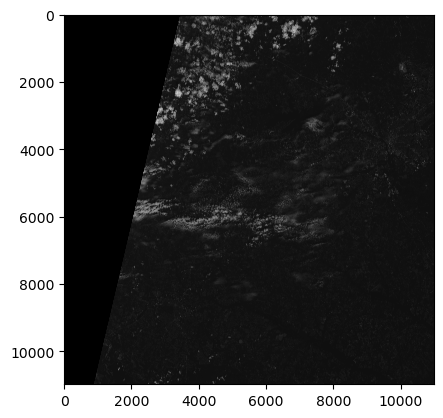

In [39]:
plt.imshow(B2, cmap='gray')

In [45]:
print(gdf_all.crs)

None


In [46]:
gdf_all = gdf_all.set_crs(epsg=4326)
gdf_all.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [47]:
# Define the days and time periods of interest
days = ['2025-08-18', '2025-08-19', '2025-08-20', '2025-09-23', '2025-09-24']
periods = {
    'am': ('05:55:00', '07:05:00'),
    'af': ('18:55:00', '20:05:00'),
    'pm': ('14:55:00', '16:05:00')
}

# Dictionary to hold the resulting dataframes
dfs_by_day_period = {}

for day in days:
    for label, (start, end) in periods.items():
        start_dt = pd.Timestamp(f"{day} {start}").tz_localize('America/New_York')
        end_dt = pd.Timestamp(f"{day} {end}").tz_localize('America/New_York')
        mask = (gdf_all['datetime'] >= start_dt) & (gdf_all['datetime'] < end_dt)
        key = f"{day}_{label}"
        dfs_by_day_period[key] = gdf_all.loc[mask].copy()

# Example: dfs_by_day_period['2025-08-18_am'] contains the 6-7am data for 2025-08-18

In [48]:
dfs_by_day_period.keys()

dict_keys(['2025-08-18_am', '2025-08-18_af', '2025-08-18_pm', '2025-08-19_am', '2025-08-19_af', '2025-08-19_pm', '2025-08-20_am', '2025-08-20_af', '2025-08-20_pm', '2025-09-23_am', '2025-09-23_af', '2025-09-23_pm', '2025-09-24_am', '2025-09-24_af', '2025-09-24_pm'])

In [50]:
for obs_period in dfs_by_day_period.keys():
    # save each dataframe as a csv
    dfs_by_day_period[obs_period].to_csv(f'exports/{obs_period}.csv', index=False)